In [1]:
#!git clone https://github.com/whyhardt/SPICE.git

In [2]:
# !pip install -e SPICE

In [ ]:
import sys
import torch

from spice import SpiceEstimator, SpiceConfig, BaseModel

sys.path.append('../../..')
from weinhardt2026.utils.benchmarking_gru import GRUModel, training
from benchmarking_ganesh2024a import get_dataset, generate_behavior, BayesianModel
from spice_ganesh2024a import SpiceModel, CONFIG

# NOTEBOOK CONFIGURATION

In [4]:
train_spice = True
train_bay = True
train_gru = True

# Load dataset

Let's load the data first with the `csv_to_dataset` method. This method returns a `SpiceDataset` object which we can use right away 

In [5]:
path_data = 'data/ganesh2024a_choice.csv'
test_blocks = (3, 6, 9)
dataset_train, dataset_test, info_dataset = get_dataset(path_data=path_data, test_blocks=test_blocks, verbose=True)

Shape of dataset: torch.Size([1176, 24, 1, 11])
Number of participants: 98
Number of actions: 2


# SPICE Setup

In [21]:
path_spice = 'params/spice_ganesh2024a_stage1.pkl'

estimator = SpiceEstimator(
    # model paramaeters
    spice_class=SPICERNN,
    spice_config=spice_config,
    n_actions=dataset_train.n_actions,
    n_participants=dataset_train.n_participants,
    
    epochs=1000,
    warmup_steps=250,
    
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    verbose=True,
    save_path_spice=path_spice,
)


In [9]:
if train_spice:
    # fitting SPICE with SINDy as RNN-regularizer
    print(f"\nStarting training on {estimator.device}...")
    estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

100%|█████████████████████████| 1000/1000 [05:06<00:00,  3.26it/s, L(Train)=0.3904713, L(Val,RNN)=0.4733270, L(Val,SINDy)=0.5085542, Conv=8.35e-05, LR=1.00e-02]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
SPICE Model (Coefficients: 29):
perception_certainty[t+1]     = 0.817 1 + 1.172 contr_diff[t]^2 
reward_learning_chosen[t+1]   = -0.115 1 + 0.888 reward_learning_chosen[t] + 0.711 reward[t] + -0.18 certainty[t] + 0.018 reward_learning_chosen^2 + -0.325 reward_learning_chosen*reward[t] + 0.051 reward_learning_chosen*certainty[t] + 0.713 reward[t]^2 + 0.379 reward[t]*certainty[t] + -0.115 certainty[t]^2 
reward_learning_unchosen[t+1] = 0.165 1 + 0.812 reward_learning_unchosen[t] + 0.13 certainty[t] + 0.011 reward_learning_unchosen^2 + -0.036 reward_learning_unchosen*certainty[t] + 0.051 certainty[t]^2 
choice_persistance[t+1]       = -0.063 1 + 0.595 choice_persistance[t]

 10%|█         | 101/1000 [00:26<04:41,  3.19it/s, loss=0.0036234, n_params=34.00+/-0.00]

Ensemble confidence filtering:
	perception_certainty: 294 -> 197 / 294 (participant, experiment, term) slots
	reward_learning_chosen: 980 -> 787 / 980 (participant, experiment, term) slots
	reward_learning_unchosen: 588 -> 311 / 588 (participant, experiment, term) slots
	choice_persistance: 1470 -> 957 / 1470 (participant, experiment, term) slots


 20%|██        | 201/1000 [00:54<03:45,  3.55it/s, loss=0.0030871, n_params=34.00+/-0.00]

Ensemble confidence filtering:
	perception_certainty: 294 -> 174 / 294 (participant, experiment, term) slots
	reward_learning_chosen: 980 -> 768 / 980 (participant, experiment, term) slots
	reward_learning_unchosen: 588 -> 275 / 588 (participant, experiment, term) slots
	choice_persistance: 1470 -> 902 / 1470 (participant, experiment, term) slots


...

Ensemble confidence filtering:
	perception_certainty: 143 -> 132 / 294 (participant, experiment, term) slots
	reward_learning_chosen: 691 -> 676 / 980 (participant, experiment, term) slots
	reward_learning_unchosen: 269 -> 264 / 588 (participant, experiment, term) slots
	choice_persistance: 864 -> 834 / 1470 (participant, experiment, term) slots


100%|██████████| 1000/1000 [04:30<00:00,  3.70it/s, loss=0.0036864, n_params=19.86+/-4.75]



Stage 2.2: SINDy coefficient estimation (multi-step shooting, K=20)


100%|██████████| 1000/1000 [04:43<00:00,  3.53it/s, K=20, loss=0.0324340, n_params=19.86+/-4.75]


Training results:
	L(Train, RNN): 0.3904713
	L(Val, RNN):   0.4733270
	L(Val, SINDy): 0.8943006

RNN training finished.
Training took 860.05 seconds.
Saving SPICE model to params/spice_ganesh2024a.pkl...


Once a model is trained and saved we can load it from the pickle file using `SpiceEstimator.load_spice(path_to_model)`

In [22]:
estimator.load_spice(path_spice)

The SPICE models can be printed to the console using `SpiceEstimator.print_spice_model(participant_id)` 

In [23]:
# Print example SPICE model
participant_id = 0
print(f"\nExample SPICE model for participant {participant_id}:")
estimator.print_spice_model(participant_id=participant_id)


Example SPICE model for participant 0:
perception_certainty[t+1]     = 0.817 1 + 1.172 contr_diff[t]^2 
reward_learning_chosen[t+1]   = -0.115 1 + 0.888 reward_learning_chosen[t] + 0.711 reward[t] + -0.18 certainty[t] + 0.018 reward_learning_chosen^2 + -0.325 reward_learning_chosen*reward[t] + 0.051 reward_learning_chosen*certainty[t] + 0.713 reward[t]^2 + 0.379 reward[t]*certainty[t] + -0.115 certainty[t]^2 
reward_learning_unchosen[t+1] = 0.165 1 + 0.812 reward_learning_unchosen[t] + 0.13 certainty[t] + 0.011 reward_learning_unchosen^2 + -0.036 reward_learning_unchosen*certainty[t] + 0.051 certainty[t]^2 
choice_persistance[t+1]       = -0.063 1 + 0.595 choice_persistance[t] + 0.124 choice[t] + -0.016 certainty[t] + -0.114 certainty_next[t+1] + 0.036 choice_persistance^2 + 0.019 choice_persistance*choice[t] + -0.157 choice_persistance*certainty[t] + 0.205 choice_persistance*certainty_next[t+1] + 0.123 choice[t]^2 + 0.192 choice[t]*certainty_next[t+1] 


# Benchmark models

## Classic benchmark model 

In [12]:
bay = BayesianModel(n_participants=info_dataset['n_participants'], batch_first=True)
path_bay = path_spice.replace('spice_', 'bay_')

In [13]:
if train_bay:
    epochs = 1000
    optimizer = torch.optim.Adam(bay.parameters(), lr=0.01)

    gru = training(
        model=bay,
        optimizer=optimizer,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        device=torch.device('cpu'),
        )
    
    torch.save(gru.state_dict(), path_bay)
    print("Trained benchmark parameters saved to " + path_bay)

Epoch 1/1000: L(Train): 0.6028429269790649; L(Test): 0.6002292037010193
Epoch 2/1000: L(Train): 0.6026435494422913; L(Test): 0.6001224517822266
Epoch 3/1000: L(Train): 0.6025003790855408; L(Test): 0.6000827550888062
Epoch 4/1000: L(Train): 0.6023517847061157; L(Test): 0.6000432372093201
Epoch 5/1000: L(Train): 0.6022629737854004; L(Test): 0.6001044511795044
Epoch 6/1000: L(Train): 0.6020733714103699; L(Test): 0.5999649167060852
Epoch 7/1000: L(Train): 0.6018921732902527; L(Test): 0.6000064611434937
Epoch 8/1000: L(Train): 0.6016889810562134; L(Test): 0.599982738494873
Epoch 9/1000: L(Train): 0.6015658974647522; L(Test): 0.5998323559761047
Epoch 10/1000: L(Train): 0.6013981103897095; L(Test): 0.5997848510742188
Epoch 11/1000: L(Train): 0.6011480689048767; L(Test): 0.5996079444885254
Epoch 12/1000: L(Train): 0.6009694933891296; L(Test): 0.5994270443916321
Epoch 13/1000: L(Train): 0.6008453965187073; L(Test): 0.5993789434432983
Epoch 14/1000: L(Train): 0.6006194949150085; L(Test): 0.59920

In [14]:
bay.load_state_dict(torch.load(path_bay))

<All keys matched successfully>

## GRU benchmark model

In [15]:
gru = GRUModel(
    n_actions=info_dataset['n_actions'], 
    n_participants=info_dataset['n_participants'],
    additional_inputs=2, 
    dropout=0.25,
    embedding_size=8,
    hidden_size=8,
    )
path_gru = path_spice.replace('spice_', 'gru_')

In [16]:
if train_gru:
    epochs = 1000
    optimizer = torch.optim.Adam(gru.parameters(), lr=0.01)

    gru = training(
        model=gru,
        optimizer=optimizer,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        device=torch.device('cpu'),
        )

    torch.save(gru.state_dict(), path_gru)
    print("Trained GRU parameters saved to " + path_gru)

Epoch 1/1000: L(Train): 0.7022047638893127; L(Test): 0.6953619718551636
Epoch 2/1000: L(Train): 0.6958208680152893; L(Test): 0.6939972043037415
Epoch 3/1000: L(Train): 0.6950287222862244; L(Test): 0.6938410401344299
Epoch 4/1000: L(Train): 0.6946113109588623; L(Test): 0.6932950019836426
Epoch 5/1000: L(Train): 0.6940969228744507; L(Test): 0.6928632259368896
Epoch 6/1000: L(Train): 0.6934958100318909; L(Test): 0.6927669644355774
Epoch 7/1000: L(Train): 0.693538248538971; L(Test): 0.6928344368934631
Epoch 8/1000: L(Train): 0.6934282779693604; L(Test): 0.6929088830947876
Epoch 9/1000: L(Train): 0.6928243637084961; L(Test): 0.6929101347923279
Epoch 10/1000: L(Train): 0.693282425403595; L(Test): 0.6928530931472778
Epoch 11/1000: L(Train): 0.6932999491691589; L(Test): 0.6927675604820251
Epoch 12/1000: L(Train): 0.6927900910377502; L(Test): 0.6926857829093933
Epoch 13/1000: L(Train): 0.6927136182785034; L(Test): 0.6926401853561401
Epoch 14/1000: L(Train): 0.6926501393318176; L(Test): 0.692631

In [17]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))

<All keys matched successfully>

# ANALYSIS

In [18]:
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals
from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions

In [ ]:
estimator.eval()
bay.eval()
gru.eval()

## Analysis of trial averaged accuracy

In [25]:
analysis_model_evaluation(
    dataset=dataset_train,
    spice_model=estimator,
    gru_model=gru,
    benchmark_model=bay,
    )

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.636894,0.143498,2.000000,0.000000,9549.998047,19103.996094,19119.916016
GRU,0.691003,0.125997,1362.000000,0.000000,7823.922852,18371.845703,29213.701172
SPICE-RNN,0.687508,0.137911,9168.000000,0.000000,7931.270508,34198.539062,107178.078125
SPICE,0.674689,0.139465,25.704081,1.797894,8329.669922,16710.748047,16915.359375


In [24]:
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator,
    gru_model=gru,
    benchmark_model=bay,
    )

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.612602,0.137542,2.000000,0.000000,3457.722656,6919.445312,6933.168457
GRU,0.635455,0.143231,1362.000000,0.000000,3199.294434,9122.588867,18468.132812
SPICE-RNN,0.639226,0.137473,9168.000000,0.000000,3157.543457,24651.085938,87558.539062
SPICE,0.627898,0.135315,25.704081,1.799939,3283.707031,6618.822266,6795.194336


## Analysis generative behavior

In [ ]:
estimator.eval()
estimator.use_sindy(False)
generated_dataset_spice = generate_behavior(
    dataset=dataset_train,
    model=estimator,
    save_dataset='data/ganesh2024a_spice_rnn.csv'
)

estimator.use_sindy(True)
generated_dataset_spice = generate_behavior(
    dataset=dataset_train,
    model=estimator,
    save_dataset='data/ganesh2024a_spice.csv'
)

generated_dataset_benchmark = generate_behavior(
    dataset=dataset_train,
    model=bay,
    save_dataset='data/ganesh2024a_benchmark.csv'
)

generated_dataset_gru = generate_behavior(
    dataset=dataset_train,
    model=gru,
    save_dataset='data/ganesh2024a_gru.csv'
)

Generating behavior...


100%|██████████| 24/24 [00:00<00:00, 341.45it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 24/24 [00:00<00:00, 1097.87it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 24/24 [00:00<00:00, 1711.41it/s]


Done generating behavior.


In [27]:
from analysis_generative import analysis_generative_behavior

Loading real from data/ganesh2024a_choice.csv...
Loading benchmark from data/ganesh2024a_benchmark.csv...
Loading gru from data/ganesh2024a_gru.csv...
Loading spice_rnn from data/ganesh2024a_spice.csv...
Loading spice from data/ganesh2024a_spice.csv...
                  Accuracy Accuracy (Low |Contrast|)  \
Model                                                  
real       0.468 +/- 0.346           0.482 +/- 0.306   
benchmark  0.706 +/- 0.174           0.652 +/- 0.169   
gru        0.675 +/- 0.225           0.641 +/- 0.212   
spice_rnn  0.776 +/- 0.189           0.750 +/- 0.202   
spice      0.776 +/- 0.189           0.750 +/- 0.202   

          Accuracy (Mid |Contrast|) Accuracy (High |Contrast|)  \
Model                                                            
real                0.472 +/- 0.402            0.449 +/- 0.352   
benchmark           0.756 +/- 0.256            0.693 +/- 0.217   
gru                 0.694 +/- 0.311            0.679 +/- 0.247   
spice_rnn           0.76

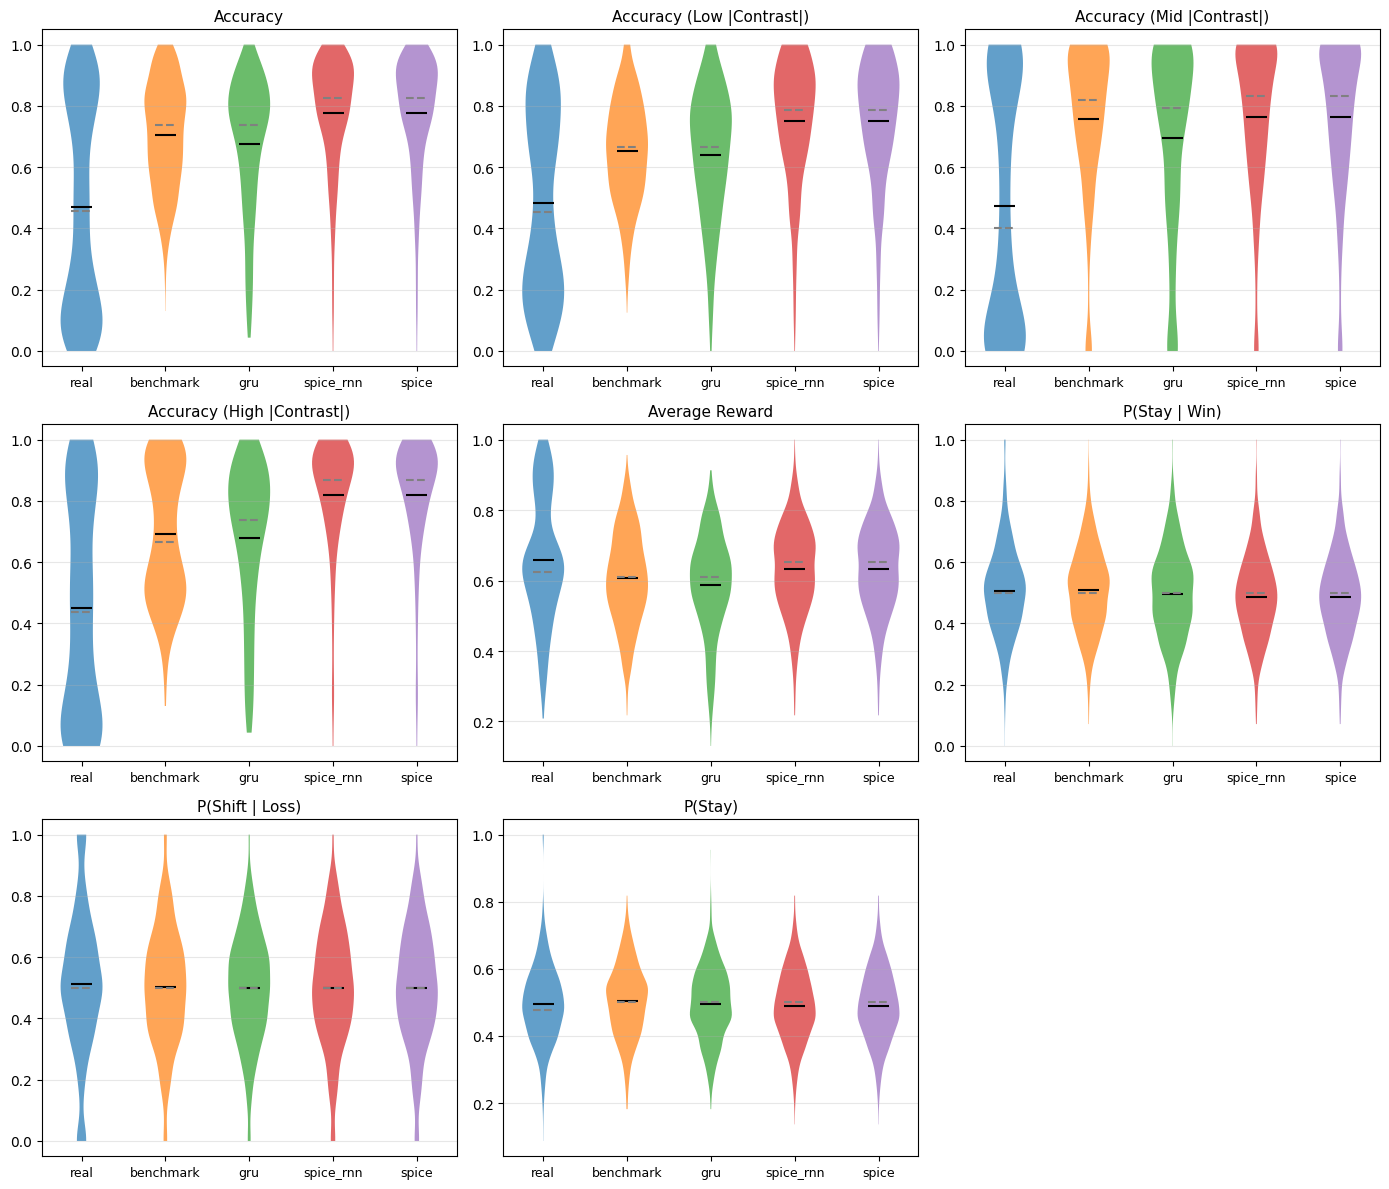


Per-metric MAE (|model_mean - real_mean|):
          Accuracy Accuracy (Low |Contrast|) Accuracy (Mid |Contrast|)  \
Model                                                                    
benchmark   0.2376                    0.1695                    0.2834   
gru         0.2062                    0.1585                    0.2214   
spice_rnn   0.3075                    0.2673                    0.2928   
spice       0.3075                    0.2673                    0.2928   

          Accuracy (High |Contrast|) Average Reward P(Stay | Win)  \
Model                                                               
benchmark                     0.2440         0.0527        0.0039   
gru                           0.2300         0.0710        0.0113   
spice_rnn                     0.3700         0.0268        0.0184   
spice                         0.3700         0.0268        0.0184   

          P(Shift | Loss) P(Stay)      Aggregate MAE  
Model                                    

(                  Accuracy Accuracy (Low |Contrast|)  \
 Model                                                  
 real       0.468 +/- 0.346           0.482 +/- 0.306   
 benchmark  0.706 +/- 0.174           0.652 +/- 0.169   
 gru        0.675 +/- 0.225           0.641 +/- 0.212   
 spice_rnn  0.776 +/- 0.189           0.750 +/- 0.202   
 spice      0.776 +/- 0.189           0.750 +/- 0.202   
 
           Accuracy (Mid |Contrast|) Accuracy (High |Contrast|)  \
 Model                                                            
 real                0.472 +/- 0.402            0.449 +/- 0.352   
 benchmark           0.756 +/- 0.256            0.693 +/- 0.217   
 gru                 0.694 +/- 0.311            0.679 +/- 0.247   
 spice_rnn           0.765 +/- 0.250            0.819 +/- 0.194   
 spice               0.765 +/- 0.250            0.819 +/- 0.194   
 
             Average Reward    P(Stay | Win)  P(Shift | Loss)          P(Stay)  
 Model                                         

In [29]:
analysis_generative_behavior(
    path_data_real='data/ganesh2024a_choice.csv',
    path_data_benchmark='data/ganesh2024a_benchmark.csv',
    path_data_gru='data/ganesh2024a_gru.csv',
    path_data_spice_rnn='data/ganesh2024a_spice.csv',
    path_data_spice='data/ganesh2024a_spice.csv',
)

## Analysis of individual differences (only SPICE)

This function analyses individual differences of the SPICE models w.r.t. the fitted SINDy coefficients.

Here you can choose between a discrete odds ratio analysis between groups (e.g. `HighAccumulatedReward` vs `LowAccumulatedReward`) or a beta-effect analysis of a continuous variable (e.g. `AccumulatedReward`).

The analyses check whether the given criterion is a good predictor of the SINDy coefficients in the model.

In [20]:
analysis_coefficients_individuals(
    path_model=path_spice,
    path_data=path_data,
    criterion="SomePerformanceColumnInDataset",
    analysis="disc", # also: "cont"
    reference="ReferenceGroupFromPerformanceColumn", # only necessary if analysis="disc"
    dir_output="../data/ganesh2024a/",
    model_class=SPICERNN,
    model_config=spice_config,
)

STEP 1: Preparing data


KeyError: 'participant'